In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import models
import torchvision.transforms.v2 as tfs_v2
import torch.nn as nn
import torch.optim as optim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img = Image.open('image.png').convert('RGB')
img_style = Image.open('img_style.png').convert('RGB')

transforms = tfs_v2.Compose([
    tfs_v2.Resize((224, 224)),
    tfs_v2.ToImage(),
    tfs_v2.ToDtype(torch.float32, scale=True)
])

img = transforms(img).unsqueeze(0)
img_style = transforms(img_style).unsqueeze(0)

img = img.to(device)
img_style = img_style.to(device)

img_create = img.clone()
img_create.requires_grad_(True) # включение градиентов для формируемого изображения

tensor([[[[0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          ...,
          [0.5451, 0.5412, 0.5490,  ..., 0.7922, 0.7961, 0.7961],
          [0.4706, 0.4706, 0.4745,  ..., 0.6784, 0.6824, 0.6824],
          [0.1608, 0.1608, 0.1608,  ..., 0.1804, 0.1804, 0.1804]],

         [[0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          ...,
          [0.2863, 0.2824, 0.2902,  ..., 0.4745, 0.4784, 0.4784],
          [0.2588, 0.2549, 0.2627,  ..., 0.4157, 0.4157, 0.4157],
          [0.1373, 0.1373, 0.1373,  ..., 0.1529, 0.1529, 0.1529]],

         [[0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0.1216, 0.1216, 0.1216],
          [0.1216, 0.1216, 0.1216,  ..., 0

In [3]:
class ModelStyle(nn.Module):
    def __init__(self):
        super().__init__()
        _model = models.vgg19(pretrained=False)
        _my_weights = "vgg19-dcbb9e9d.pth"
        _state_dict = torch.load(_my_weights)
        _model.load_state_dict(_state_dict)
        self.mf = _model.features
        self.mf.requires_grad_(False)
        self.mf.eval()
        self.idx_out = (0, 5, 10, 19, 28, 34)
        self.num_style_layers = len(self.idx_out) - 1

    def forward(self, x):
        outputs = []
        for idx, layer in enumerate(self.mf):
            x = layer(x)
            if idx in self.idx_out:
                outputs.append(x.squeeze(0))
        
        return outputs

In [4]:
def get_content_loss(base_content, target):
    "Потери по контенту"
    return torch.mean(torch.square(base_content - target)) # подробнее разобрать формулу


def gram_matrix(x):
    "Построение матриц Грама для расчета степени стилизации"
    channels = x.size(dim=0)
    g = x.view(channels, -1)
    gram = torch.mm(g, g.T) / g.size(dim=1)
    return gram


def get_style_loss(base_style, gram_target):
    "Функция для расчета общих потерь по стилю"
    _loss = 0
    style_weights = [1.0, 0.8, 0.5, 0.3, 0.1]
    i = 0
    for base, target in zip(base_style, gram_target):
        gram_style = gram_matrix(base)
        _loss += style_weights[i] * torch.mean(torch.square(gram_style - target))
        i += 1
    
    return _loss

c:\Users\Great_Ded\Desktop\уник\ML\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Great_Ded\Desktop\уник\ML\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Эпоха: 0, loss:  2628.9802
Эпоха: 1, loss:  2199.4167
Эпоха: 2, loss:  1764.3127
Эпоха: 3, loss:  1424.8625
Эпоха: 4, loss:  1171.9362
Эпоха: 5, loss:  991.5815
Эпоха: 6, loss:  864.6516
Эпоха: 7, loss:  769.3496
Эпоха: 8, loss:  692.8521
Эпоха: 9, loss:  630.4534
Эпоха: 10, loss:  579.9073
Эпоха: 11, loss:  539.1339
Эпоха: 12, loss:  505.3080
Эпоха: 13, loss:  476.1610
Эпоха: 14, loss:  450.2842
Эпоха: 15, loss:  426.9709
Эпоха: 16, loss:  405.7409
Эпоха: 17, loss:  386.1424
Эпоха: 18, loss:  367.9600
Эпоха: 19, loss:  351.0713
Эпоха: 20, loss:  335.5520
Эпоха: 21, loss:  321.4220
Эпоха: 22, loss:  308.3958
Эпоха: 23, loss:  296.3691
Эпоха: 24, loss:  285.2336
Эпоха: 25, loss:  274.9127
Эпоха: 26, loss:  265.3176
Эпоха: 27, loss:  256.3478
Эпоха: 28, loss:  247.9577
Эпоха: 29, loss:  240.1113
Эпоха: 30, loss:  232.7182
Эпоха: 31, loss:  225.7696
Эпоха: 32, loss:  219.2404
Эпоха: 33, loss:  213.0581
Эпоха: 34, loss:  207.2679
Эпоха: 35, loss:  201.7936
Эпоха: 36, loss:  196.6071
Эпоха:

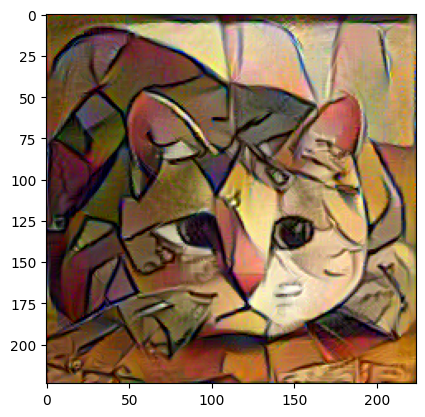

In [5]:
model = ModelStyle()
model = model.to(device)
outputs_img = model(img)
outputs_img_style = model(img_style)

gram_matrix_style = [gram_matrix(x) for x in outputs_img_style[:model.num_style_layers]]

content_weight = 1
style_weight = 1000
best_loss = float("inf")
patience_counter = 0
patience = 10
epochs = 1000
best_img = img_create.clone()

optimizer = optim.Adam(params=[img_create], lr=0.01)

for _e in range(epochs):
    outputs_img_create = model(img_create)

    loss_content = get_content_loss(outputs_img_create[-1], outputs_img[-1])
    loss_style = get_style_loss(outputs_img_create, gram_matrix_style)
    loss = content_weight * loss_content + style_weight * loss_style

    print(f'Эпоха: {_e}, loss: {loss.item(): .4f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img_create.data.clamp_(0, 1)

    if loss < best_loss:
        best_loss = loss
        best_img = img_create.clone()
        patience_counter = 0
        torch.save(model.state_dict(), "best_style_model.pth")
    
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'Процесс прекращен на эпохе {_e + 1}')
        break


x = best_img.detach().squeeze()
x = x.to("cpu")
low, hi = torch.amin(x), torch.amax(x)
x = (x - low) / (hi - low) * 255.0
x = x.permute(1, 2, 0)
x = x.numpy()
x = np.clip(x, 0, 255).astype('uint8')

image = Image.fromarray(x, 'RGB')
image.save("result.jpg")

plt.imshow(x)
plt.show()